<a href="https://colab.research.google.com/github/Shubham-Niture/Programming_Work/blob/main/FashionMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

(train_img, train_lable), (test_val_img, test_val_lable) = tf.keras.datasets.fashion_mnist.load_data()

train_img = train_img / 255.
test_val_img = test_val_img / 255.

test_img = test_val_img[:5000]
val_img = test_val_img[5000:]
test_lable = test_val_lable[:5000]
val_lable = test_val_lable[5000:]

print(train_img.shape, test_img.shape, val_img.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28) (5000, 28, 28) (5000, 28, 28)


In [2]:
import numpy as np

print(np.unique(train_lable))

[0 1 2 3 4 5 6 7 8 9]


In [3]:
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

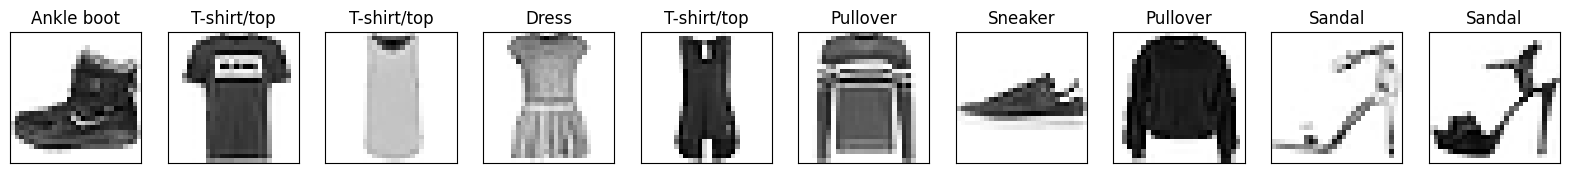

In [4]:
from matplotlib import pyplot as plt
import math

def show_images(images , lables):
  n_rows = math.ceil(len(images) / 10)
  plt.figure(figsize = (20,8))
  for i , image in enumerate(images):
    ax = plt.subplot(n_rows, 10 , i+1, xticks = [], yticks = [])
    plt.imshow(image, cmap='Greys')
    plt.title(classes[lables[i]])

show_images(train_img[:10], train_lable[:10])
plt.show();



In [5]:
def reshape(images):
  images = images.reshape(images.shape[0], -1)
  return images

train_img = reshape(train_img)
test_img = reshape(test_img)
val_img = reshape(val_img)

print(train_img.shape, test_img.shape, val_img.shape)

(60000, 784) (5000, 784) (5000, 784)


In [6]:
from numpy.random import seed
import tensorflow as tf

seed(14)
tf.random.set_seed(19)

In [9]:
from tensorflow.keras import layers , models
from tensorflow.keras.callbacks import EarlyStopping

num_class = 10

In [14]:
model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape= (784,)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])


model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True
)


history = model.fit(train_img, train_lable, validation_data = [val_img, val_lable], epochs = 30, batch_size =64, verbose=1)

model.summary()

Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.8242 - loss: 0.4881 - val_accuracy: 0.8498 - val_loss: 0.4115
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.8668 - loss: 0.3618 - val_accuracy: 0.8666 - val_loss: 0.3694
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.8795 - loss: 0.3254 - val_accuracy: 0.8660 - val_loss: 0.3756
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8879 - loss: 0.2998 - val_accuracy: 0.8710 - val_loss: 0.3634
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.8946 - loss: 0.2810 - val_accuracy: 0.8804 - val_loss: 0.3420
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9001 - loss: 0.2650 - val_accuracy: 0.8808 - val_loss: 0.3478
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9034 - loss: 0.2536 - val_accuracy: 0.8888 - val_loss: 0.3226
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9085 - loss: 0.2411 - 

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,607,456 (6.13 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,071,638 (4.09 MB)

In [15]:
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(test_img, test_lable, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8892 - loss: 0.4529
Test Loss: 0.45286035537719727
Test Accuracy: 0.88919997215271
